# Pricing optimization
### Jimmy Azar

## Introduction

We'll explore optimal pricing based on demand curve estimation. We are provided information on the willingness-to-pay (wtp) of consumers for a given product based on a survey. Willingness-to-pay is the maximum amount a consumer is willing to pay for purchasing a given product.   

We'll experiment with fitting a distribution on wtp data, and then we'll derive the demand curve and find the optimal price to set for the product so as to maximize profitability.

## Explore the data

We load the data, inspect the values, and view some useful statistics. Based on this data, 60 customers were surveyed.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# explore the data
path_to_file = '../data/wtp.txt'
data = pd.read_csv(path_to_file)
print(data.head())
print(data.shape)

data['wtp'].count()
print(data.describe())

   wtp
0   48
1   56
2   50
3   42
4   49
(60, 1)
             wtp
count  60.000000
mean   49.516667
std     4.443589
min    39.000000
25%    47.000000
50%    49.000000
75%    52.000000
max    61.000000


## Fit a normal distribution

We first create a density plot of the wtp data. The plot resembles the Normal probability distribution function.

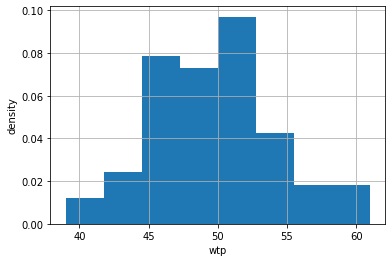

In [2]:
# fit a normal distribution
plt.hist(data['wtp'], bins=8, density=True)
plt.xlabel('wtp')
plt.ylabel("density")
plt.grid()
plt.show()

### Method of moments 

We may fit a normal distribution using the method of moments by setting the theoretical moments (mean and standard deviation) to the sample moments derived from the data. Therefore, to fit a normal distribution over the 1D data, we need to compute the sample mean and standard deviation. Next, we plot the theoretical normal density function over the range of values that wtp takes. We also add to the plot the actual densities obtained using the histogram.

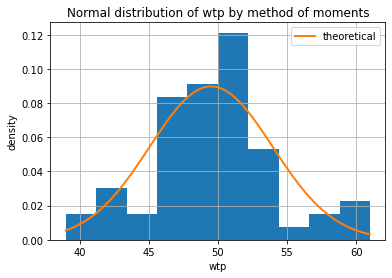

In [3]:
# method of moments
from scipy import stats

mean = data['wtp'].mean()
std = data['wtp'].std()
x = np.linspace(data['wtp'].min(), data['wtp'].max(), 100)
y = stats.norm.pdf(x=x, loc=mean, scale=std)

plt.hist(data['wtp'], density=True)
plt.plot(x, y, lw=2, label='theoretical')
plt.xlabel('wtp')
plt.ylabel('density')
plt.title('Normal distribution of wtp by method of moments')
plt.grid()
plt.legend()
plt.show()

### Method of maximum-likelihood

We can instead fit a normal distribution using the method of maximum likelihood.

We plot the theoretical normal density function over the range of values that wtp takes but now using the maximum likelihood estimates. As before, we superimpose the actual densities obtained from the histogram plot.

Note that for a normal distribution, the maximum likelihood (ML) estimates can be theoretically derived. The ML estimate of the mean will be the same as the sample mean, whereas the ML estimate of the variance is $\sum_i (X_i-\overline{X})^2/n$, where $n$ is the number of samples. The sample (unbiased) variance uses $n-1$ instead in the denominator. Therefore, for a normal distribution, the ML estimate of the standard deviation can be obtained from the sample standard deviation (computed in the previous section) by multiplying by $\sqrt{(n-1)/n}$.

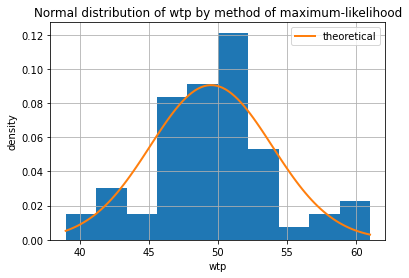

4.406403169126594

In [4]:
# method of maximum-likelihood
mean, std = stats.distributions.norm.fit(data['wtp'])
y = stats.norm.pdf(x, mean, std)

plt.hist(data['wtp'], density=True)
plt.plot(x, y, lw=2, label='theoretical')
plt.xlabel('wtp')
plt.ylabel('density')
plt.title('Normal distribution of wtp by method of maximum-likelihood')
plt.grid()
plt.legend()
plt.show()

# same as 'std' by ML
data['wtp'].std() * np.sqrt((data['wtp'].count() - 1)/(data['wtp'].count()))

## Fit a logistic distribution

We can fit a logistic distribution (pdf) instead of a normal distribution. Note that the logistic **function** which has a sigmoid shape is the cumulative distribution function (cdf) of the logistic probability **distribution** function. We also explore both the method of moments and maximum likehood for fitting the model.

### Method of moments 

We can fit a logistic distribution using the method of moments by setting the theoretical parameters, "location" (or mean) and "scale", to the sample location and scale derived from the data.

Next, we plot the theoretical logistic probability density function over the range of values that wtp takes. We also add the actual densities obtained from the histogram plot.

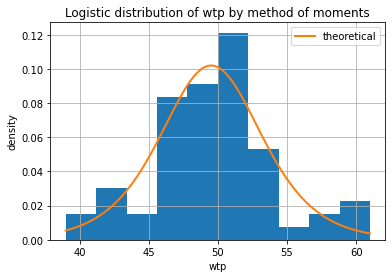

In [5]:
# method of moments
loc = data['wtp'].mean()
scale = np.sqrt(data['wtp'].var() * 3 / np.pi**2)
x = np.linspace(data['wtp'].min(), data['wtp'].max(), 100)
y = stats.logistic.pdf(x=x, loc=loc, scale=scale)

plt.hist(data['wtp'], density=True)
plt.plot(x, y, lw=2, label='theoretical')
plt.xlabel('wtp')
plt.ylabel('density')
plt.title('Logistic distribution of wtp by method of moments')
plt.grid()
plt.legend()
plt.show()

### Method of maximum-likelihood

We can instead use the method of maximum likelihood.

We plot the theoretical logistic density function over the range of values that wtp takes but now using the maximum likelihood estimate. We also superimpose the actual densities obtained from the histogram plot.

Both the normal and logistic distributions fit very well over the wtp data. We'll use the logistic distribution from here on and proceed to estimate the demand curve.

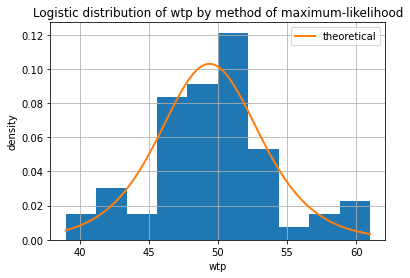

In [6]:
# method of maximum-likelihood
loc, scale = stats.distributions.logistic.fit(data['wtp'])
y = stats.logistic.pdf(x, loc, scale)

plt.hist(data['wtp'], density=True)
plt.plot(x, y, lw=2, label='theoretical')
plt.xlabel('wtp')
plt.ylabel('density')
plt.title('Logistic distribution of wtp by method of maximum-likelihood')
plt.grid()
plt.legend()
plt.show()

## Demand curve estimation

Given the fitted wtp logistic distribution, for a given price $p$, the demand corresponds to the area to the right tail of the distribution, i.e. $P(wtp \geq p)$ which is equal to $1-P(wtp<p) = 1-\text{cdf}(p)$. Strictly speaking, demand, as a count, is equal to this area multiplied by the market size.

We'll set the market size to 10,000 and plot the demand curve as a function of price for the range of prices given in the wtp data.

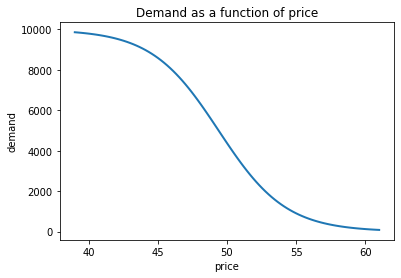

In [7]:
# demand curve estimation
market_size = 10000
demand_values = market_size * (1 - stats.logistic.cdf(x=x, loc=loc, scale=scale))

plt.plot(x, demand_values, lw=2)
plt.xlabel('price')
plt.ylabel('demand')
plt.title('Demand as a function of price')
plt.show()

## Price optimization 

At a given price, $p$, the profit is equal to the demand at $p$ multiplied by ($price - cost$).

In what follows, we assume the cost of a product unit is $\$ 15$ and the market size is 10,000.

We find the optimal price corresponding to maximum profit. Finally, we plot the profit as a function of price for a selected range of values in order to visually validate the result.

maximum profit: 261949.02378059743
optimal price: 43.666666666666664


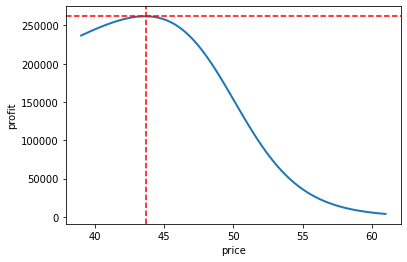

In [8]:
# price optimization
cost = 15
profit_values = demand_values * (x - cost)

profit_opt = max(profit_values)
price_opt = x[np.argmax(profit_values)]
print(f'maximum profit: {profit_opt}')
print(f'optimal price: {price_opt}')

plt.plot(x, profit_values, lw=2)
plt.axhline(y=profit_opt, c='r', linestyle='--')
plt.axvline(x=price_opt, c='r', linestyle='--')
plt.xlabel('price')
plt.ylabel('profit')
plt.show()